In [1]:
from tensorflow.keras.models import load_model
model = load_model('blood_group_detection_model.keras')

c:\Users\LENOVO\anaconda3\envs\genre_nlp\lib\site-packages\keras\src\saving\saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [4]:
# Loop over all layers and print them to verify ResNet50 layer location
for i, layer in enumerate(model.layers):
    print(i, layer.name, layer.trainable)



0 input_layer True
1 conv1_pad False
2 conv1_conv False
3 conv1_bn False
4 conv1_relu False
5 pool1_pad False
6 pool1_pool False
7 conv2_block1_1_conv False
8 conv2_block1_1_bn False
9 conv2_block1_1_relu False
10 conv2_block1_2_conv False
11 conv2_block1_2_bn False
12 conv2_block1_2_relu False
13 conv2_block1_0_conv False
14 conv2_block1_3_conv False
15 conv2_block1_0_bn False
16 conv2_block1_3_bn False
17 conv2_block1_add False
18 conv2_block1_out False
19 conv2_block2_1_conv False
20 conv2_block2_1_bn False
21 conv2_block2_1_relu False
22 conv2_block2_2_conv False
23 conv2_block2_2_bn False
24 conv2_block2_2_relu False
25 conv2_block2_3_conv False
26 conv2_block2_3_bn False
27 conv2_block2_add False
28 conv2_block2_out False
29 conv2_block3_1_conv False
30 conv2_block3_1_bn False
31 conv2_block3_1_relu False
32 conv2_block3_2_conv False
33 conv2_block3_2_bn False
34 conv2_block3_2_relu False
35 conv2_block3_3_conv False
36 conv2_block3_3_bn False
37 conv2_block3_add False
38 conv2_b

In [5]:
# Unfreeze last 30 layers
for layer in model.layers[-30:]:
    layer.trainable = True


In [6]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),   # Very low LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [9]:
import os
import pandas as pd
import glob

# Your dataset path
file_path = 'dataset_blood_group'

# List of all filepaths
filepaths = list(glob.glob(file_path+'/**/*.*'))

# Create labels from folder names
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

filepath_series = pd.Series(filepaths, name='Filepath').astype(str)
labels_series = pd.Series(labels, name='Label')

data = pd.concat([filepath_series, labels_series], axis=1)
data = data.sample(frac=1).reset_index(drop=True)

data.head()


,Filepath,Label
0,dataset_blood_group\AB+\cluster_4_3558.BMP,AB+
1,dataset_blood_group\O-\cluster_7_38.BMP,O-
2,dataset_blood_group\AB-\cluster_5_233.BMP,AB-
3,dataset_blood_group\B+\cluster_2_5186.BMP,B+
4,dataset_blood_group\O-\cluster_7_57.BMP,O-


In [10]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(data, test_size=0.25, random_state=42)


In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=train,
    x_col='Filepath',
    y_col='Label',
    target_size=(256, 256),
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42
)

valid_gen = test_datagen.flow_from_dataframe(
    dataframe=test,
    x_col='Filepath',
    y_col='Label',
    target_size=(256, 256),
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)


Found 4500 validated image filenames belonging to 8 classes.
Found 1500 validated image filenames belonging to 8 classes.


In [13]:
from tensorflow.keras.callbacks import EarlyStopping

my_callbacks = [EarlyStopping(
    monitor='val_accuracy',
    min_delta=0,
    patience=2,
    mode='auto'
)]


In [14]:
history_finetune = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=5,                  # 5 epochs is sufficient for fine-tuning
    callbacks=my_callbacks
)


c:\Users\LENOVO\anaconda3\envs\genre_nlp\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 678s 5s/step - accuracy: 0.6460 - loss: 1.1203 - val_accuracy: 0.8067 - val_loss: 0.5205
Epoch 2/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 790s 6s/step - accuracy: 0.8880 - loss: 0.3210 - val_accuracy: 0.8447 - val_loss: 0.4015
Epoch 3/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 782s 6s/step - accuracy: 0.9397 - loss: 0.2059 - val_accuracy: 0.8567 - val_loss: 0.3855
Epoch 4/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 764s 5s/step - accuracy: 0.9705 - loss: 0.1320 - val_accuracy: 0.8500 - val_loss: 0.3862
Epoch 5/5
141/141 ━━━━━━━━━━━━━━━━━━━━ 713s 5s/step - accuracy: 0.9872 - loss: 0.0879 - val_accuracy: 0.8647 - val_loss: 0.3756


In [15]:
test_loss, test_acc = model.evaluate(valid_gen)
print(f"Test Accuracy after Fine-Tuning: {test_acc * 100:.2f}%")


47/47 ━━━━━━━━━━━━━━━━━━━━ 188s 4s/step - accuracy: 0.8647 - loss: 0.3859
Test Accuracy after Fine-Tuning: 86.47%


In [16]:
model.save("blood_group_detection_model_finetuned.keras")

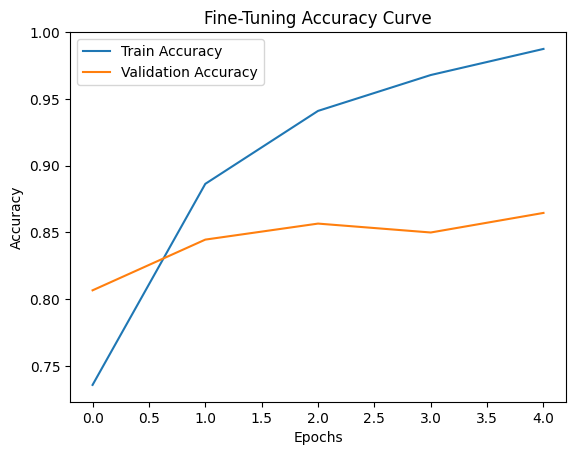

In [17]:
import matplotlib.pyplot as plt

plt.plot(history_finetune.history['accuracy'], label='Train Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')
plt.title('Fine-Tuning Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


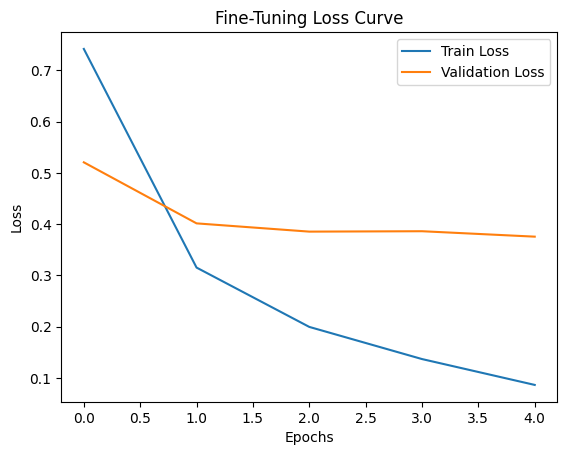

In [18]:
plt.plot(history_finetune.history['loss'], label='Train Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')
plt.title('Fine-Tuning Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


47/47 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step
Classification Report After Fine-Tuning:
              precision    recall  f1-score   support

          A+       0.87      0.90      0.88       124
          A-       0.87      0.80      0.83       251
         AB+       0.78      0.87      0.83       155
         AB-       0.86      0.92      0.89       189
          B+       0.88      0.80      0.84       174
          B-       0.89      0.97      0.93       207
          O+       0.86      0.85      0.85       214
          O-       0.90      0.84      0.87       186

    accuracy                           0.86      1500
   macro avg       0.86      0.87      0.86      1500
weighted avg       0.87      0.86      0.86      1500



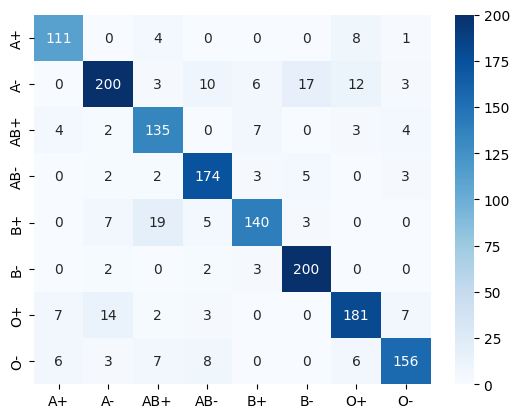

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

predictions = model.predict(valid_gen)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = valid_gen.classes

print("Classification Report After Fine-Tuning:")
print(classification_report(true_classes, predicted_classes, target_names=valid_gen.class_indices.keys()))

cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=valid_gen.class_indices.keys(),
            yticklabels=valid_gen.class_indices.keys())
plt.show()
